# EQUIPO LFM | Aprendizaje automatico | Árboles de decisión pre-pruning

Integrantes:
- Alejandro Loredo Zuleta
- Ezequiel Frega
- Javier Mariosa

## Importar librerías

In [126]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import tree, metrics
from sklearn.tree import DecisionTreeClassifier #Arboles de decisión para Clasificaciòn
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


## Cargar dataset
Dataset clásico de hongos **Agaricus–Lepiota**.


In [127]:
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSV_0nnBuRbEN8dvWe84US2_f7JQrC_ZAa3lQAwyFERKsDqLwO864wkGXsHHE8j8A/pub?gid=808341260&single=true&output=csv"
dfAgaricusLepiota = pd.read_csv(url)
dfAgaricusLepiota.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## Descripción breve


In [128]:
dfAgaricusLepiota.shape

(8124, 23)

Este dataset contiene información de **8.124 muestras de hongos** de la familia Agaricus y Lepiota.

In [129]:
dfAgaricusLepiota.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

Atributos

1. class → clase del hongo:

* e: comestible, p: venenoso

2. cap-shape → forma del sombrero:

* b: bell (acampanado), c: conical, x: convex, f: flat, k: knobbed, s: sunken

3. cap-surface → superficie del sombrero:

* f: fibrous, g: grooves, y: scaly, s: smooth

4. cap-color → color del sombrero:

* n: brown, b: buff, c: cinnamon, g: gray, r: green, p: pink, u: purple, e: red, w: white, y: yellow

5. bruises → presencia de daños:

* t: bruises, f: no

6. odor → olor:

* a: almond, l: anise, c: creosote, y: fishy, f: foul, m: musty, n: none, p: pungent, s: spicy

7. gill-attachment → unión de las láminas:

* a: attached, d: descending, f: free, n: notched

8. gill-spacing → separación de las láminas:

* c: close, w: crowded, d: distant

9. gill-size → tamaño de las láminas:

* b: broad, n: narrow

10. gill-color → color de las láminas:

* k: black, n: brown, b: buff, h: chocolate, g: gray, r: green, o: orange, p: pink, u: purple, e: red, w: white, y: yellow

11. stalk-shape → forma del tallo:

* e: enlarging, t: tapering

12. stalk-root → raíz del tallo:

* b: bulbous, c: club, u: cup, e: equal, z: rhizomorphs, r: rooted, ?: missing

13. stalk-surface-above-ring → superficie del tallo por encima del anillo:

* f: fibrous, y: scaly, k: silky, s: smooth

14. stalk-surface-below-ring → superficie del tallo por debajo del anillo:

* f: fibrous, y: scaly, k: silky, s: smooth

15. stalk-color-above-ring → color del tallo por encima del anillo:

* n: brown, b: buff, c: cinnamon, g: gray, o: orange, p: pink, e: red, w: white, y: yellow

16. stalk-color-below-ring → color del tallo por debajo del anillo:

* n: brown, b: buff, c: cinnamon, g: gray, o: orange, p: pink, e: red, w: white, y: yellow

17. veil-type → tipo de velo:

* p: partial, u: universal

18. veil-color → color del velo:

* n: brown, o: orange, w: white, y: yellow

19. ring-number → número de anillos:

* n: none, o: one, t: two

20. ring-type → tipo de anillo:

* c: cobwebby, e: evanescent, f: flaring, l: large, n: none, p: pendant, s: sheathing, z: zone

21. spore-print-color → color de la impresión de esporas:

* k: black, n: brown, b: buff, h: chocolate, r: green, o: orange, u: purple, w: white, y: yellow

22. population → distribución en la población:

* a: abundant, c: clustered, n: numerous, s: scattered, v: several, y: solitary

23. habitat → hábitat:

* g: grasses, l: leaves, m: meadows, p: paths, u: urban, w: waste, d: woods

## Tratamiento de faltantes y variables poco informativas
- `stalk-root` tiene ~30% faltantes (`?`) → se elimina.
- Variables con **casi toda la masa en una sola categoría** aportan poco: se eliminan.


In [130]:
# Faltantes en stalk-root
dfAgaricusLepiota['stalk-root'].value_counts()

,count
stalk-root,
b,3776
?,2480
e,1120
c,556
r,192


In [131]:
dfAgaricusLepiota['class'].value_counts()

,count
class,
e,4208
p,3916


In [132]:
dfAgaricusLepiota.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Eliminamos las columnas dominadas por una sola categoría, ya que no aportan información útil para la clasificación.  

Por ejemplo, en **`ring-number`**, la categoría **“o”** aparece en casi todas las instancias, por lo que este atributo tiene bajo poder de discriminación y no resulta relevante para el modelo.


In [133]:
# Eliminar columnas
cols_drop = ['stalk-root','gill-attachment','gill-spacing','veil-type','veil-color','ring-number']
dfAgaricusLepiota = dfAgaricusLepiota.drop(columns=cols_drop)

dfAgaricusLepiota.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-size                 8124 non-null   object
 7   gill-color                8124 non-null   object
 8   stalk-shape               8124 non-null   object
 9   stalk-surface-above-ring  8124 non-null   object
 10  stalk-surface-below-ring  8124 non-null   object
 11  stalk-color-above-ring    8124 non-null   object
 12  stalk-color-below-ring    8124 non-null   object
 13  ring-type                 8124 non-null   object
 14  spore-print-color       

## Análisis exploratorio (bivariado con la clase)

A continuación se muestra gráficamente las frecuencias de cada una de las variables y su relación contra la clase objetivo

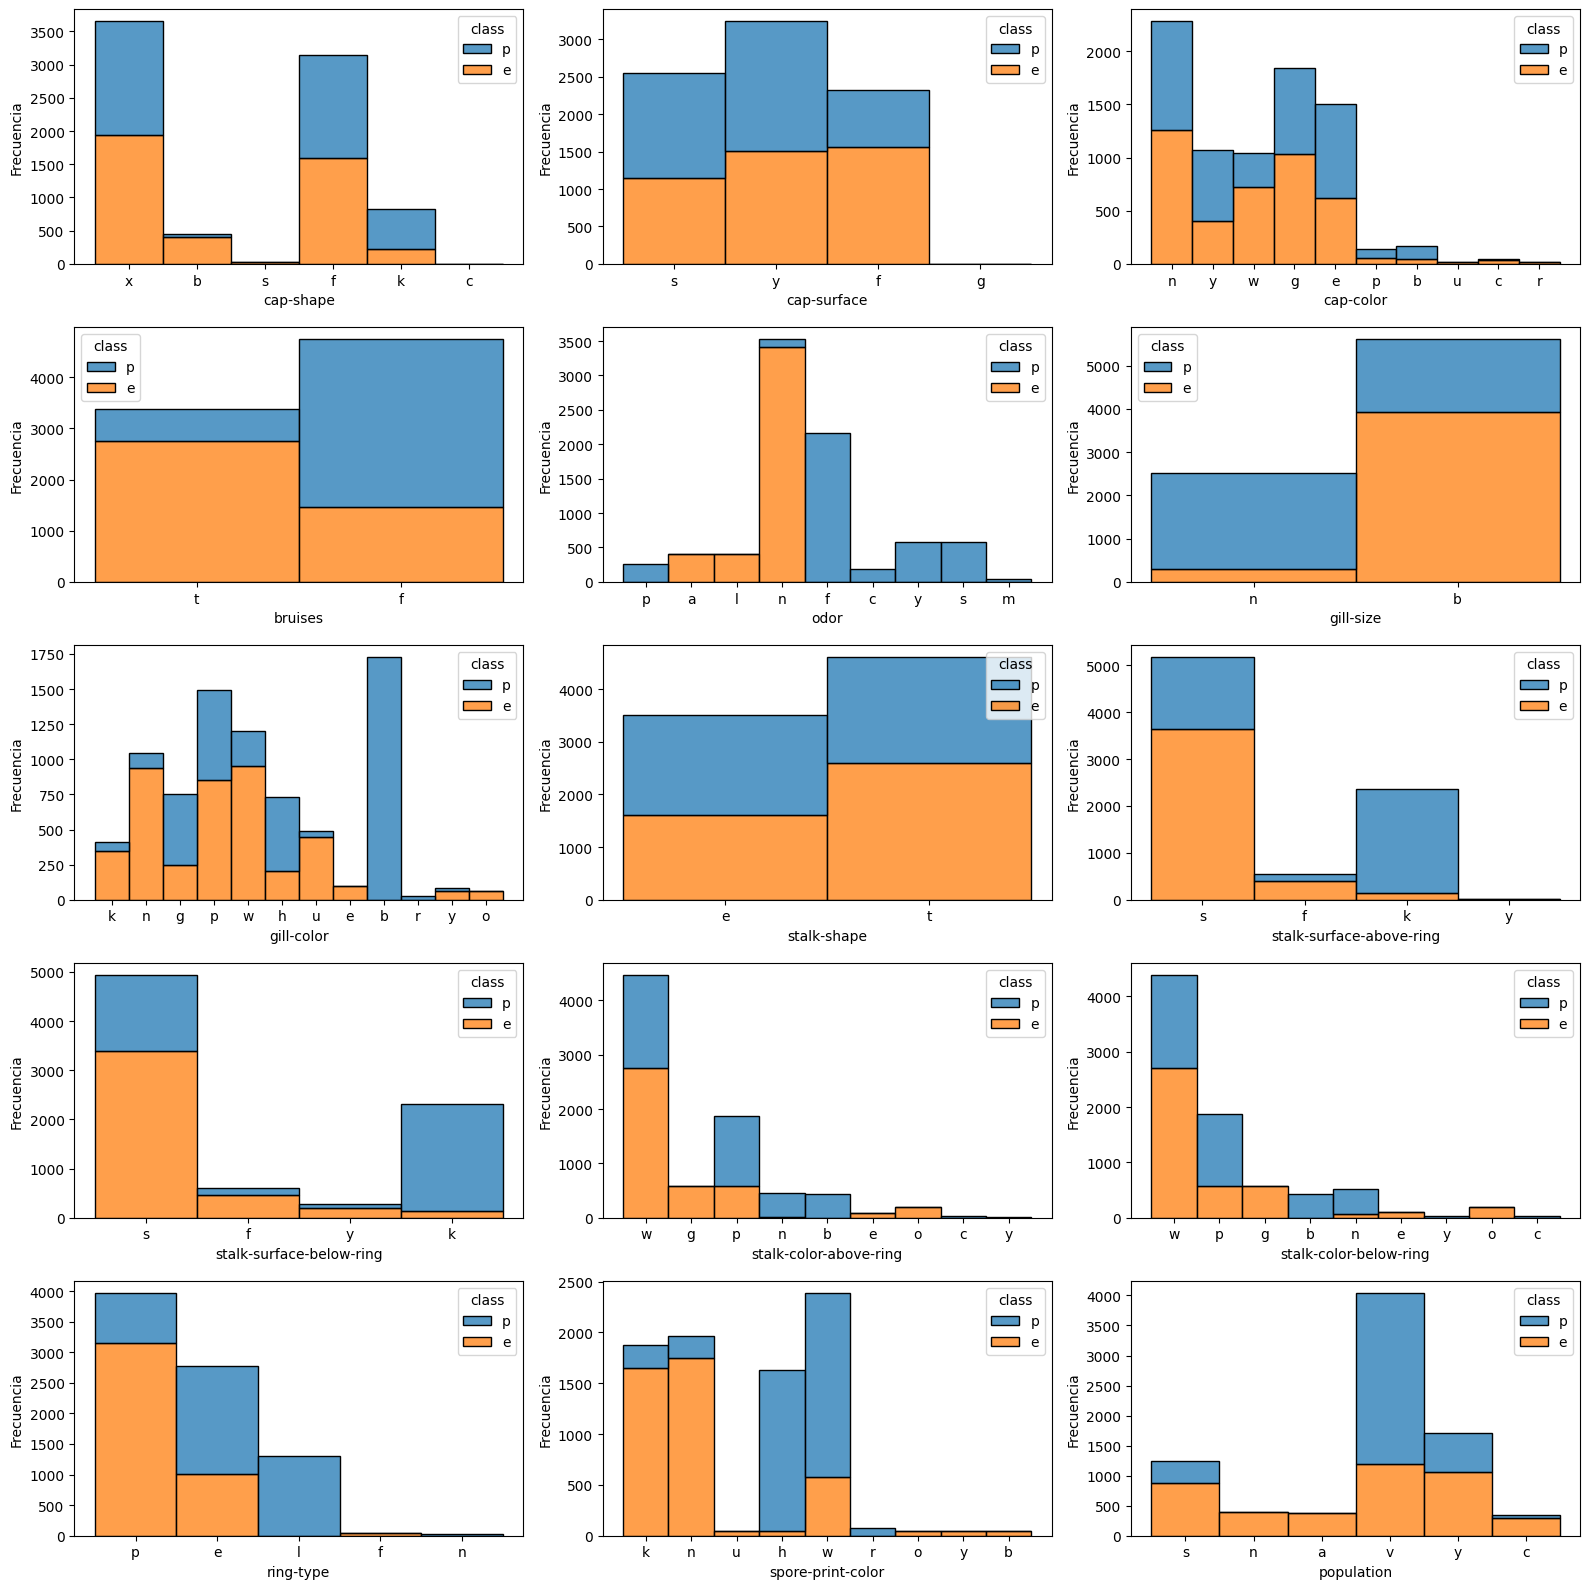

In [134]:
NombresAtributos = dfAgaricusLepiota.columns

fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(16,16), sharex=False)
idx = 0
for i in range(5):
    for j in range(3):
        # saltear si nos quedamos sin columnas
        idx += 1
        if idx >= len(NombresAtributos):
            ax[i, j].axis('off')
            continue
        c = NombresAtributos[idx]
        if c == 'class':
            ax[i, j].axis('off')
            continue
        sns.histplot(data=dfAgaricusLepiota, x=c, hue='class', multiple='stack', ax=ax[i, j])
        ax[i, j].set_xlabel(c)
        ax[i, j].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


* Muy discriminantes: odor, gill-size, bruises, spore-print-color, ring-type.

* Moderadamente útiles: stalk-surface, gill-color, cap-color.

* Poco útiles: cap-shape, cap-surface, stalk-shape.

La idea es elegir atributos que realmente dividan la variable objetivo (class).

# Exploración y selección analítica de atributos

### Chi-cuadrado | gl | p-value


In [135]:
# Lista de atributos
atributos = ["cap-shape", "cap-surface", "cap-color", "bruises", "odor", "gill-size", "gill-color", "stalk-shape", "stalk-surface-above-ring", "stalk-surface-below-ring", "stalk-color-above-ring", "stalk-color-below-ring", "ring-type", "spore-print-color", "population", "habitat"]

# Recorremos y mostramos resultados resumidos
for v in atributos:
    tabla = pd.crosstab(index=dfAgaricusLepiota['class'], columns=dfAgaricusLepiota[v])
    chi2, p, dof, expected = stats.chi2_contingency(tabla)

    conclusion = "Asociado a la clase" if p < 0.05 else "No asociado"

    print(f"Atributo: {v}")
    print(f"   Chi2 = {chi2:.2f}, gl = {dof}, p-value = {p:.4e} → {conclusion}")
    print("-"*60)


Atributo: cap-shape
   Chi2 = 489.92, gl = 5, p-value = 1.1965e-103 → Asociado a la clase
------------------------------------------------------------
Atributo: cap-surface
   Chi2 = 315.04, gl = 3, p-value = 5.5184e-68 → Asociado a la clase
------------------------------------------------------------
Atributo: cap-color
   Chi2 = 387.60, gl = 9, p-value = 6.0558e-78 → Asociado a la clase
------------------------------------------------------------
Atributo: bruises
   Chi2 = 2041.42, gl = 1, p-value = 0.0000e+00 → Asociado a la clase
------------------------------------------------------------
Atributo: odor
   Chi2 = 7659.73, gl = 8, p-value = 0.0000e+00 → Asociado a la clase
------------------------------------------------------------
Atributo: gill-size
   Chi2 = 2366.83, gl = 1, p-value = 0.0000e+00 → Asociado a la clase
------------------------------------------------------------
Atributo: gill-color
   Chi2 = 3765.71, gl = 11, p-value = 0.0000e+00 → Asociado a la clase
---------

## Selección de Atributos para Árbol de Decisión

Para elaborar un árbol de decisión basado exclusivamente en los indicadores estadísticos proporcionados ($\chi^2$, $gl$ y $p\text{-value}$), los cuatro atributos seleccionados serían:

- **odor** ($\chi^2 = 7659.73$)
- **spore-print-color** ($\chi^2 = 4602.03$)
- **gill-color** ($\chi^2 = 3765.71$)
- **ring-type** ($\chi^2 = 2956.62$)

---

## Justificación

La selección se fundamenta en los principios de la estadística inferencial aplicados a la selección de características (*feature selection*) para modelos predictivos:

### 1. Significancia Estadística ($p\text{-value}$)

Los cuatro atributos presentan un $p\text{-value} = 0.0000e+00$.

En términos académicos, esto indica que la probabilidad de que la asociación observada entre el atributo y la clase sea producto del azar es prácticamente nula. Al ser menores al nivel de significancia estándar ($\alpha = 0.05$ o $0.01$), se rechaza la hipótesis nula de independencia, confirmando que estos atributos poseen una relación dependiente y altamente significativa con la variable objetivo.

---

### 2. Magnitud del Estadístico Chi-cuadrado ($\chi^2$)

El valor de $\chi^2$ mide la discrepancia entre las frecuencias observadas y las esperadas bajo el supuesto de independencia.

En la construcción de árboles de decisión (especialmente en algoritmos como CHAID), se priorizan las variables con los valores de $\chi^2$ más altos, ya que estos indican una mayor fuerza de asociación y, por ende, un mayor poder discriminatorio.

Los cuatro atributos elegidos encabezan la lista con los valores más elevados del dataset, lo que garantiza que las particiones (*splits*) del árbol generen nodos con la mayor pureza posible.

---

### 3. Relación con los Grados de Libertad ($gl$)

Aunque el estadístico $\chi^2$ tiende a aumentar con el número de categorías (reflejado en los grados de libertad), los valores obtenidos para estos atributos son tan elevados que superan por órdenes de magnitud a los demás, incluso comparándolos con atributos de $gl$ similares.

Por ejemplo:

- **odor** ($gl = 8$) tiene un $\chi^2$ casi el doble que **spore-print-color** ($gl = 8$)

Esto lo posiciona como el predictor primario o "raíz" más probable para el árbol, al ofrecer la mayor reducción de incertidumbre estadística.

---

## Conclusión

Se eligen estos atributos porque maximizan la dependencia estadística con la clase, asegurando que el modelo de clasificación sea robusto y que las reglas de decisión extraídas tengan el mayor respaldo empírico según la prueba de independencia de Pearson.

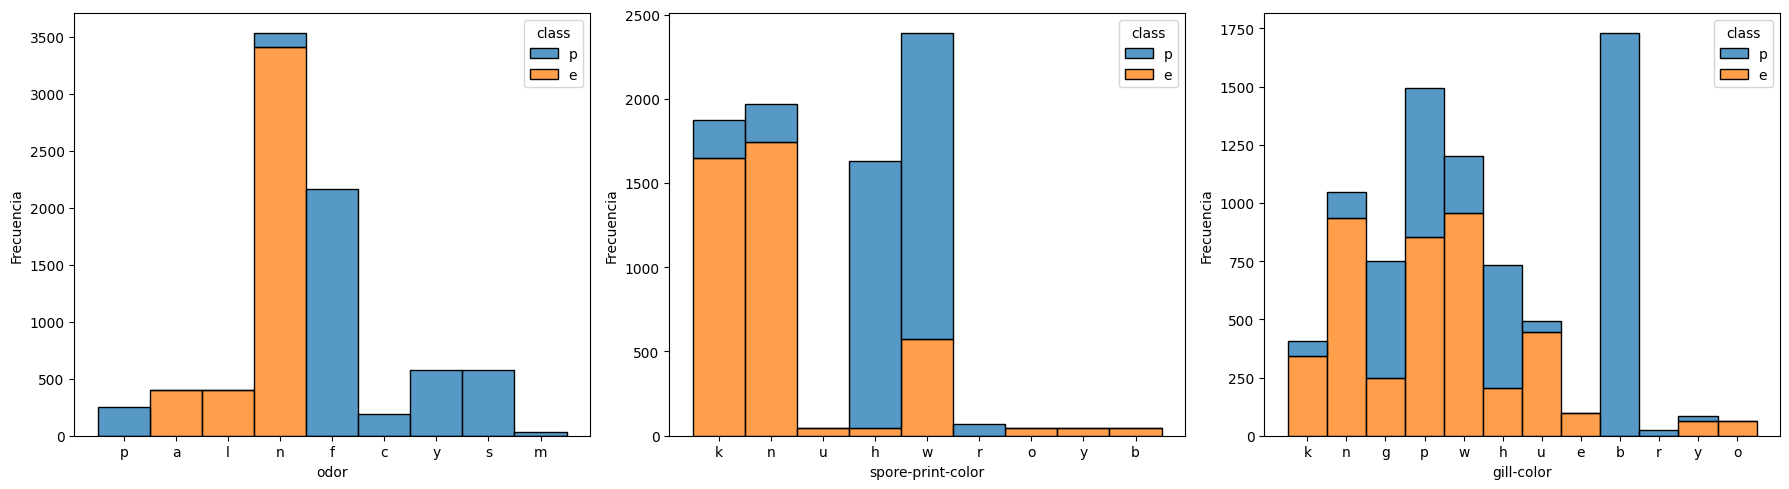

In [136]:
# Atributos seleccionados: uno de cada grupo
atributos_seleccionados = ["odor", "spore-print-color", "gill-color"]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharex=False)

for i, atributo in enumerate(atributos_seleccionados):
    sns.histplot(
        data=dfAgaricusLepiota,
        x=atributo,
        hue="class",
        multiple="stack",
        ax=ax[i]
    )
    ax[i].set_xlabel(atributo)
    ax[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


###Tabla de contingencia de los atributos seleccionados a partir de los gráficos




In [137]:
# Matrices de contingencia (class vs variable)
XNombresAtributos = ["odor", "spore-print-color", "gill-color"]
for v in XNombresAtributos:
    print(f'\n[Contingencia] class vs {v}')
    print(pd.crosstab(index=dfAgaricusLepiota['class'], columns=dfAgaricusLepiota[v]))



[Contingencia] class vs odor
odor     a    c     f    l   m     n    p    s    y
class                                              
e      400    0     0  400   0  3408    0    0    0
p        0  192  2160    0  36   120  256  576  576

[Contingencia] class vs spore-print-color
spore-print-color   b     h     k     n   o   r   u     w   y
class                                                        
e                  48    48  1648  1744  48   0  48   576  48
p                   0  1584   224   224   0  72   0  1812   0

[Contingencia] class vs gill-color
gill-color     b   e    g    h    k    n   o    p   r    u    w   y
class                                                              
e              0  96  248  204  344  936  64  852   0  444  956  64
p           1728   0  504  528   64  112   0  640  24   48  246  22


# Data Preparation: Encoding

Los algoritmos en scikit-learn no entienden directamente variables categóricas (texto), por lo que hay que codificarlas:

- **X (variables de entrada)** = se transforma con OneHotEncoder → crea columnas binarias (0/1) para cada categoría.  
- **y (variable objetivo)** = se transforma con OneHotEncoder → crea columnas binarias (0/1) para cada categoría  
- **train/test** = 70/30 con `stratify` para mantener el balance de clases.  
- **random_state=42** para **reproducibilidad**.

In [138]:
# Seleccionar X, y (aún categóricas)
X = dfAgaricusLepiota[XNombresAtributos].values
y = dfAgaricusLepiota['class'].values

# OneHot para X (binario por categoría)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_dummies = encoder.fit_transform(X)

# Nombres legibles de las columnas codificadas
encoded_feature_names = []
for i, cat in enumerate(encoder.categories_):
    for feature_val in cat:
        encoded_feature_names.append(f"{XNombresAtributos[i]}_No es_{feature_val}")

# LabelEncoder para y (e→0, p→1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split 70/30 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X_dummies, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)

X_train.shape, X_test.shape


((5686, 30), (2438, 30))

# Pre-Pruning (GINI & MAX_DEPTH=4)

Se procede a realizar un arbol de decisión con pre-pruning siguiendo los siguientes parámetros de configuración:

- **Modelo:** `DecisionTreeClassifier`  
- **Criterio:** `gini` (grado de impureza)  
- **Profundidad:** `max_depth=4`
- **random_state=42:**


In [139]:
# Árbol con profundidad máxima 4
arbol1 = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
arbol1.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

## Interpretación del árbol
- La **raíz** pregunta por la variable con mayor poder de separación.  
- En cada nodo: `gini` (impureza), `samples` (instancias), `value` \[e, p], `class` (mayoritaria).  
- Colores: naranja = **e**, azul = **p**.


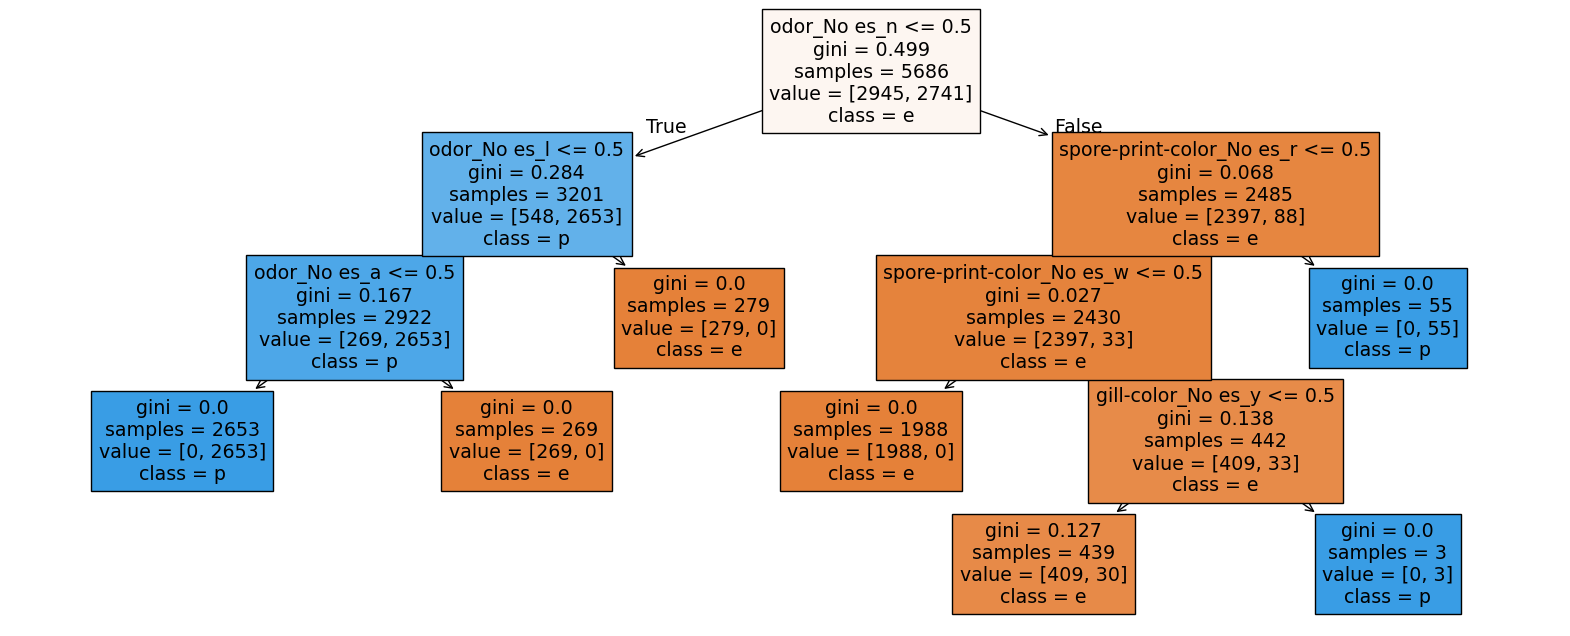

In [140]:
# Después se grafica el árbol con:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), dpi=100)

tree.plot_tree(arbol1,
               feature_names=encoded_feature_names,  # Use encoded feature names
               class_names=le.classes_,
               filled=True)
fig.savefig('arbol1.png')

En el gráfico se muestra el árbol entrenado con **profundidad máxima 4**.  
Cada nodo representa una pregunta sobre una característica del hongo, y a partir de la respuesta (True/False) se dividen las instancias.

- En la parte superior está la **raíz del árbol**. La primera división se hace según el atributo **`gill-size`**, que resultó ser una de las variables con mayor poder de separación entre comestibles (`e`) y venenosos (`p`).  
- A partir de esa división, el árbol sigue evaluando otros atributos como **`spore-print-color`** (color de impresión de esporas) y **`bruises`** (presencia de magulladuras).  
- En cada nodo se muestra:
  - **entropy**: el grado de pureza del nodo (0 = totalmente puro, 1 = muy mezclado).  
  - **samples**: cantidad de instancias en ese nodo.  
  - **value**: distribución de instancias entre las clases (`[e, p]`).  
  - **class**: la clase mayoritaria asignada por el modelo en ese nodo.  

Los nodos coloreados indican la **predicción de clase**:  
- Naranja = comestibles (`e`)  
- Azul = venenosos (`p`)  

👉 Al limitar la profundidad a 3, el árbol logra ser **más simple y legible**, mostrando las **reglas principales** que permiten distinguir entre hongos comestibles y venenosos sin caer en sobreajuste.


## Matriz de confusión

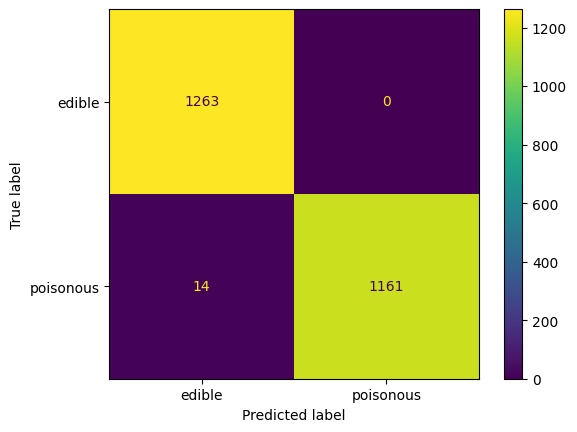

In [141]:
y_pred = arbol1.predict(X_test)

# Volver a etiquetas originales para lectura
y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(y_pred)

mc = confusion_matrix(y_test_original, y_pred_original)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=['edible','poisonous'])
disp.plot()
plt.show()

## Reporte de clasificación

In [142]:
print(classification_report(y_test_original, y_pred_original))

              precision    recall  f1-score   support

           e       0.99      1.00      0.99      1263
           p       1.00      0.99      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



## ✅ Conclusiones

La matriz de confusión muestra que el modelo clasifica correctamente la gran mayoría de los casos:  
- 1263 hongos comestibles fueron predichos correctamente como comestibles.  
- 1161 hongos venenosos fueron clasificados correctamente como venenosos.  
- 14 homgos comestibles se confundieron con venenosos y 0 venenosos fueron predichos como comestibles.  

En términos de métricas:  
- **Precisión (precision):** 0.99 para comestibles y 1 para venenosos.  
- **Exhaustividad (recall):** 1 para comestibles y 0.99 para venenosos.  
- **F1-score:** 0.99 para ambas clases.  
- **Exactitud global (accuracy):** 0.99.  

👉 Esto significa que el modelo tiene un desempeño **muy alto** en la clasificación.

# Pre-Pruning (GINI & MAX_DEPTH=2)

- **Modelo:** `DecisionTreeClassifier`  
- **Criterio:** `gini` (grado de impureza)  
- **Profundidad:** `max_depth=4`
- **random_state=42:**


In [143]:
# Árbol con profundidad máxima 2
arbol2 = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42)
arbol2.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=2, random_state=42)

## Interpretación del árbol
- La **raíz** pregunta por la variable con mayor poder de separación.  
- En cada nodo: `gini` (impureza), `samples` (instancias), `value` \[e, p], `class` (mayoritaria).  
- Colores: naranja = **e**, azul = **p**.


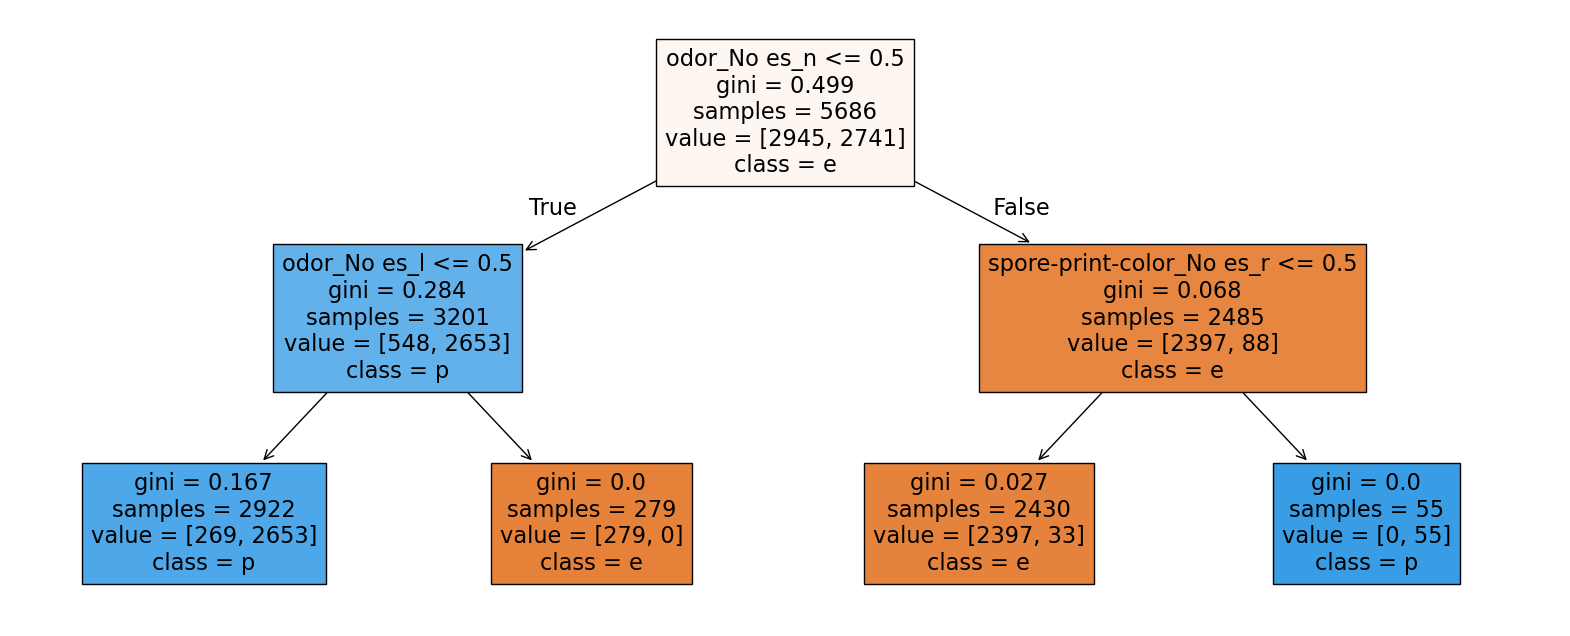

In [144]:
# Después se grafica el árbol con:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), dpi=100)

tree.plot_tree(arbol2,
               feature_names=encoded_feature_names,  # Use encoded feature names
               class_names=le.classes_,
               filled=True)
fig.savefig('arbol2.png')

## Matriz de confusión



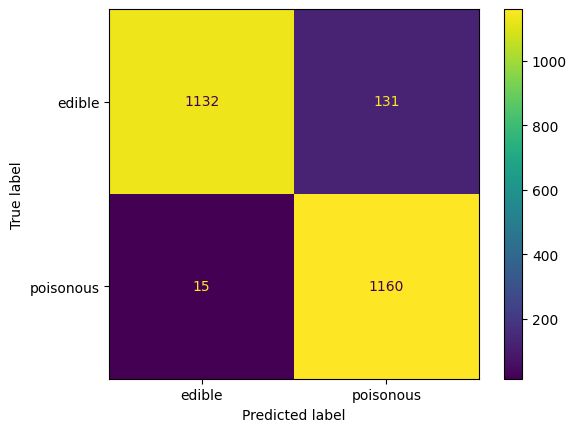

In [145]:
y_pred2 = arbol2.predict(X_test)

# Volver a etiquetas originales para lectura
y_test_original2 = le.inverse_transform(y_test)
y_pred_original2 = le.inverse_transform(y_pred2)

mc2 = confusion_matrix(y_test_original2, y_pred_original2)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=mc2, display_labels=['edible','poisonous'])
disp.plot()
plt.show()

## Reporte de clasificación

In [146]:
print(classification_report(y_test_original2, y_pred_original2))

              precision    recall  f1-score   support

           e       0.99      0.90      0.94      1263
           p       0.90      0.99      0.94      1175

    accuracy                           0.94      2438
   macro avg       0.94      0.94      0.94      2438
weighted avg       0.94      0.94      0.94      2438



## ✅ Conclusiones:

La matriz de confusión muestra que el modelo clasifica correctamente la gran mayoría de los casos:  
- 1132 hongos comestibles fueron predichos correctamente como comestibles.  
- 1160 hongos venenosos fueron clasificados correctamente como venenosos.  
- 131 homgos comestibles se confundieron con venenosos y 15 venenosos fueron predichos como comestibles.  

En términos de métricas:  
- **Precisión (precision):** 0.99 para comestibles y 0.9 para venenosos.  
- **Exhaustividad (recall):** 0.9 para comestibles y 0.99 para venenosos.  
- **F1-score:** 0.94 para ambas clases.  
- **Exactitud global (accuracy):** 0.94.

Los resultados obtenidos indican que al limitar la profundidad del arbol a 2 niveles, si bien el árbol obtenido es más simple su desempeño predictivo es muy inferior al obtenido con 4 niveles de profundidad lo cual deja en claro la importancia de esta variable en este contexto.

# Sin pre-pruning

In [147]:
arbol3 = DecisionTreeClassifier(criterion='gini', random_state=42)
arbol3.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Interpretacion del arbol

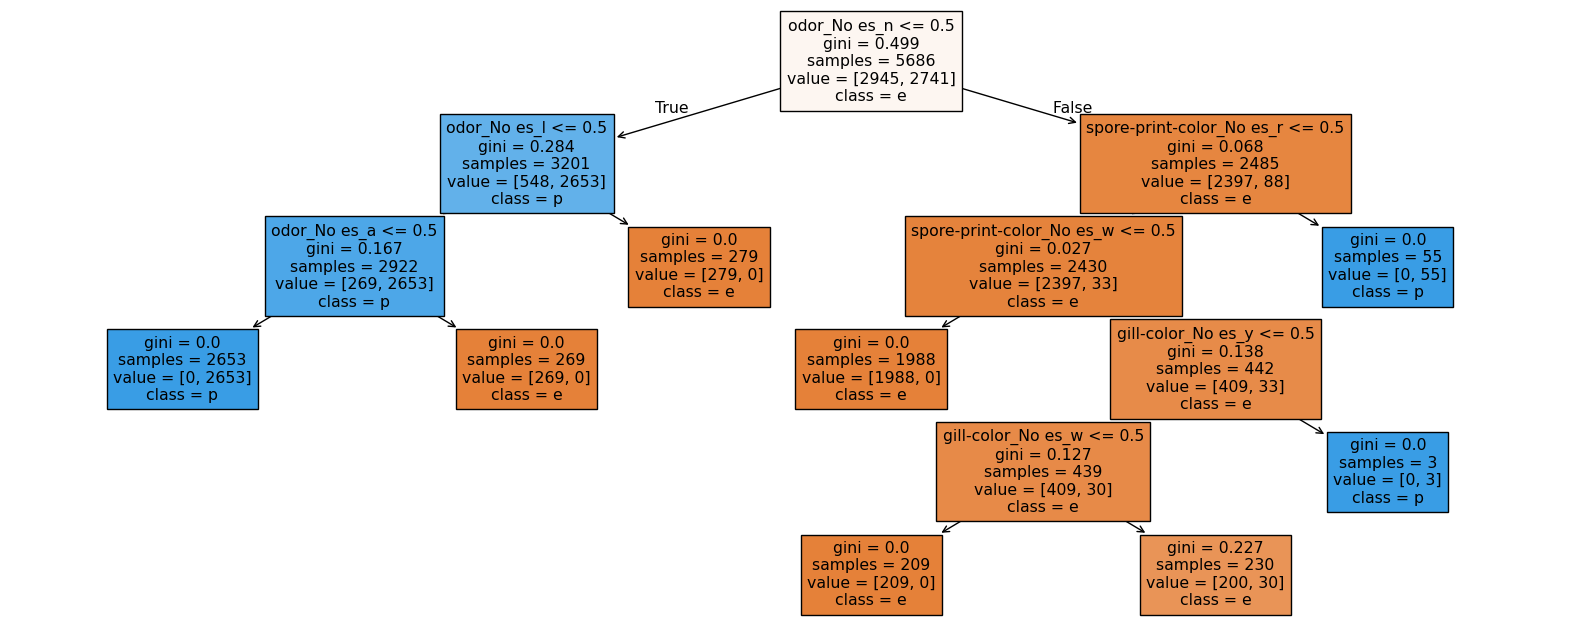

In [148]:
# Después se grafica el árbol con:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), dpi=100)

tree.plot_tree(arbol3,
               feature_names=encoded_feature_names,  # Use encoded feature names
               class_names=le.classes_,
               filled=True)
fig.savefig('arbol3.png')

Evaluacion

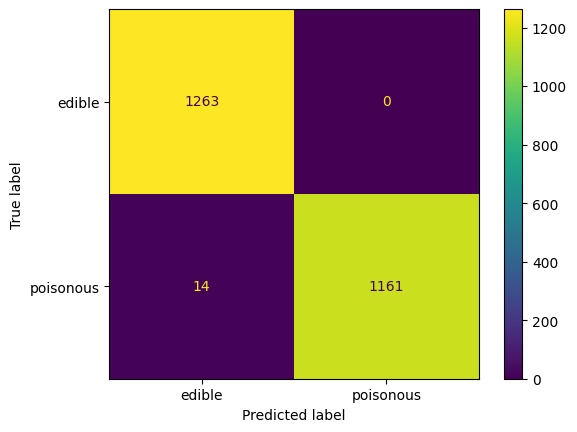

              precision    recall  f1-score   support

           e       0.99      1.00      0.99      1263
           p       1.00      0.99      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



In [149]:
y_pred_3 = arbol3.predict(X_test)

# Volver a etiquetas originales para lectura
y_test_original_3 = le.inverse_transform(y_test)
y_pred_original_3 = le.inverse_transform(y_pred_3)

mc3 = confusion_matrix(y_test_original_3, y_pred_original_3)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=mc3, display_labels=['edible','poisonous'])
disp.plot()
plt.show()

print(classification_report(y_test_original_3, y_pred_original_3))

## ✅ Conclusiones

Si bien este arbol alcanzó 5 niveles de profundidad, los resultados de la matriz de confusión e informe de clasificación fueron identicos a los obtenidos para el arbol de decision con pre-pruning y 4 niveles de profundidad.

👉 Esto significa que el modelo tiene un desempeño **muy alto** en la clasificación y posiblemente que con el criterio empleado (GINI) este es el límite biologico de detección de este dataset en base a los atributos seleccionados del dataset para su elaboración.

# Opcional - Random Forest

In [150]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

In [151]:
acc_rf = accuracy_score(y_test, y_pred_rf)

print("RANDOM FOREST")
print("Accuracy en prueba:", acc_rf)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy en prueba: 0.9942575881870386

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1263
           1       1.00      0.99      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



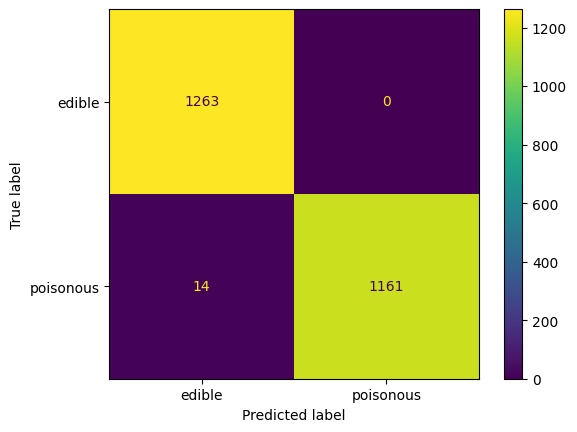

              precision    recall  f1-score   support

           e       0.99      1.00      0.99      1263
           p       1.00      0.99      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



In [152]:
# Volver a etiquetas originales para lectura
y_test_original_rf = le.inverse_transform(y_test)
y_pred_original_rf = le.inverse_transform(y_pred_rf)

mc4 = confusion_matrix(y_test_original_rf, y_pred_original_rf)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=mc4, display_labels=['edible','poisonous'])
disp.plot()
plt.show()

print(classification_report(y_test_original_rf, y_pred_original_rf))

## ✅ Conclusiones

Dado que los resultados analíticos obtenidos han sido los mismos que para el caso de los árboles sin pre=pruning y con pre=pruning de 4 niveles esto apoya la conclusión previa de que se ha alcanzado límite biologico de detección de este dataset en base a los atributos seleccionados del dataset para su elaboración con estas técnicas.